In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [3]:
from data_science.plots import plot_confusion_matrix

In [4]:
def plot_feature_importances(
    model: RandomForestClassifier,
    feature_names: list[str],
    *,
    palette: str = 'pastel',
    figsize: tuple[int, int] = (10, 6),
    dpi: int = 120,
) -> None:
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances,
    })

    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=figsize, dpi=dpi)
    sns.barplot(
        x='Importance',
        y='Feature',
        data=feature_importance_df,
        palette=palette,
        hue='Importance',
    )
    plt.title('Random Forest Feature Importance')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature Name')
    plt.tight_layout()
    plt.legend().remove()
    plt.show()


## Data


In [ ]:
data = pd.read_csv(
    './../../data/wheat-seeds.csv',
    names=[
        'area',
        'perimeter',
        'compactness',
        'length of kernel',
        'width of kernel',
        'asymmetry coefficient',
        'length of groove',
        'type',
    ],
    header=None,
)

In [6]:
label_map = {1: 'Kama', 2: 'Rosa', 3: 'Canadian'}
data['type'] = data['type'].map(label_map)

## Prepare Data


In [7]:
RANDOM_STATE = 42
np.random.default_rng(RANDOM_STATE)

Generator(PCG64) at 0x12CFFA340

In [8]:
X = data.drop(columns=['type'])
y = data['type']

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

## Random Forest Classifier


### Model with default parameters


In [11]:
rf_default = RandomForestClassifier(random_state=RANDOM_STATE)
rf_default.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred_default = rf_default.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred_default)
print(f'Accuracy: {accuracy * 100:.2f}%')
precision = precision_score(y_test, y_pred_default, average='weighted')
print(f'Precision: {precision * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_default))

Accuracy: 83.33%
Precision: 84.86%

Classification Report:
              precision    recall  f1-score   support

    Canadian       0.86      0.71      0.77        17
        Kama       0.64      0.82      0.72        11
        Rosa       1.00      1.00      1.00        14

    accuracy                           0.83        42
   macro avg       0.83      0.84      0.83        42
weighted avg       0.85      0.83      0.84        42



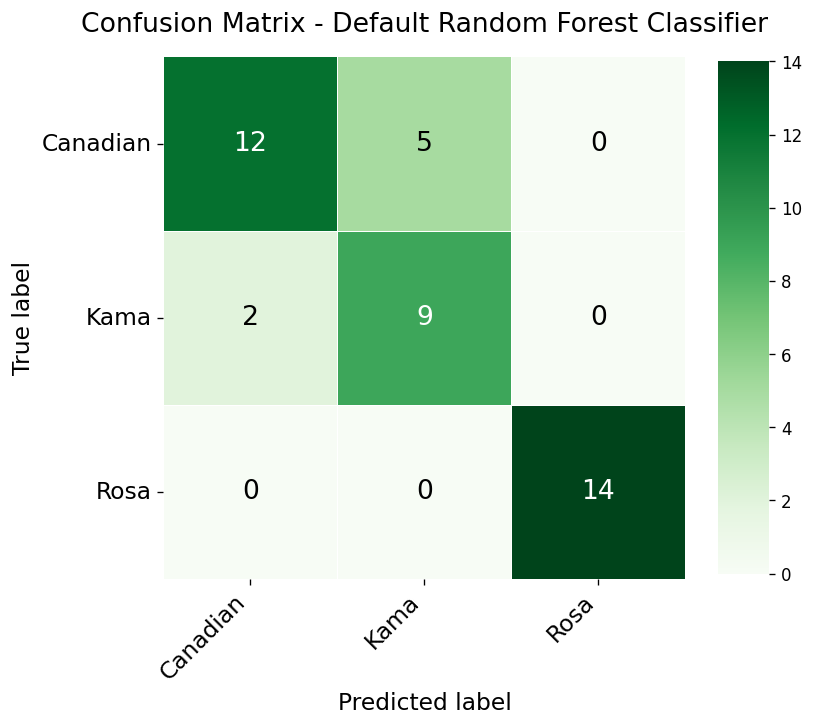

In [ ]:
cm_default = confusion_matrix(y_test, y_pred_default)
default_classes = np.unique(np.r_[y_test, y_pred_default])
plot_confusion_matrix(
    cm_default,
    default_classes,
    title='Confusion Matrix - Default Random Forest Classifier',
)

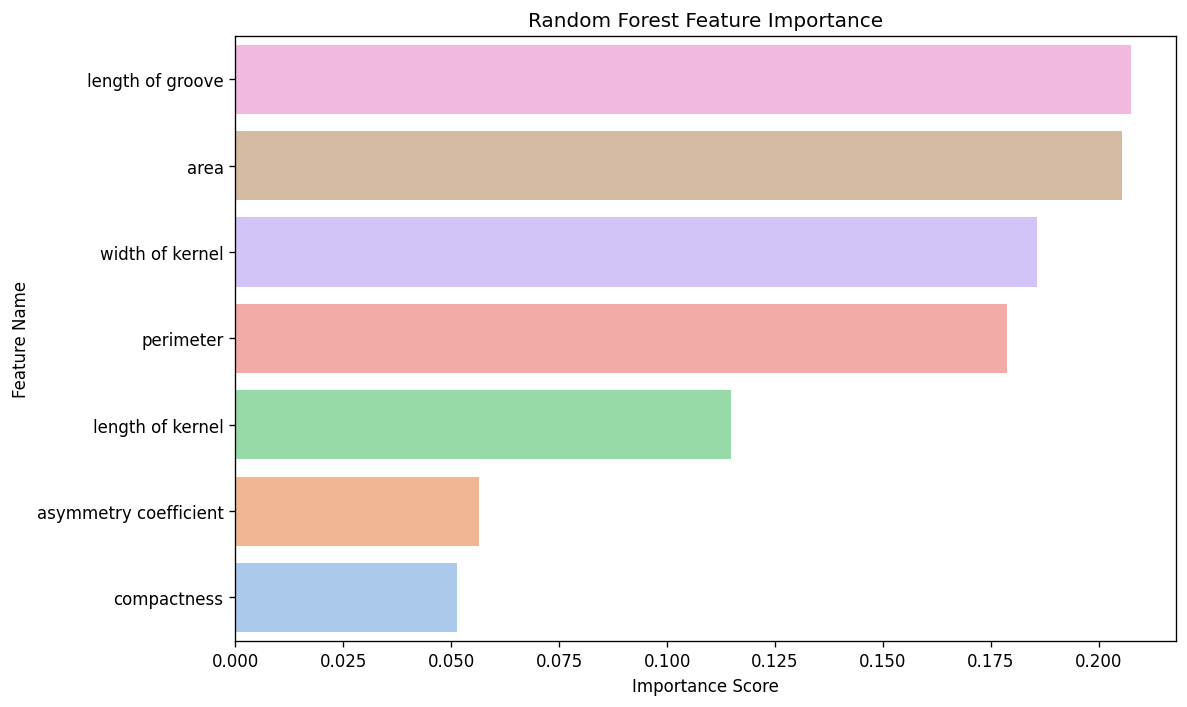

In [15]:
plot_feature_importances(rf_default , X.columns.tolist())

### Model with custom parameters


In [16]:
rf_custom = RandomForestClassifier(
    criterion='entropy',
    n_estimators=300,
    # max_depth=10,
    # min_samples_split=5,
    # min_samples_leaf=2,
    random_state=RANDOM_STATE,
)
rf_custom.fit(X_train, y_train)

,n_estimators,300
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred_custom = rf_custom.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred_custom)
print(f'Accuracy: {accuracy * 100:.2f}%')
precision = precision_score(y_test, y_pred_custom, average='weighted')
print(f'Precision: {precision * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_custom))

Accuracy: 88.10%
Precision: 88.39%

Classification Report:
              precision    recall  f1-score   support

    Canadian       0.88      0.82      0.85        17
        Kama       0.75      0.82      0.78        11
        Rosa       1.00      1.00      1.00        14

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42



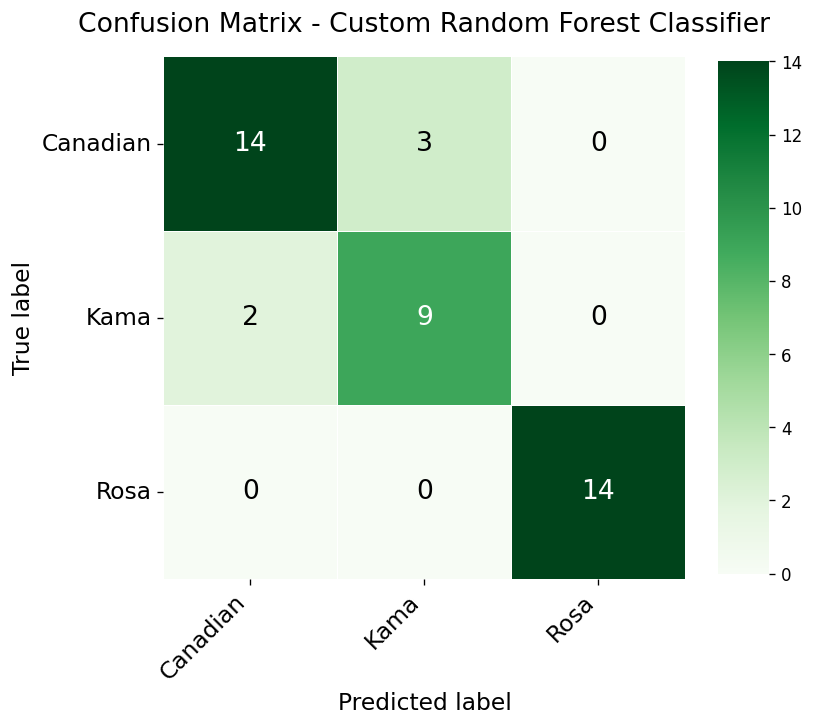

In [ ]:
cm_custom = confusion_matrix(y_test, y_pred_custom)
custom_classes = np.unique(np.r_[y_test, y_pred_custom])
plot_confusion_matrix(
    cm_custom,
    custom_classes,
    title='Confusion Matrix - Custom Random Forest Classifier',
)

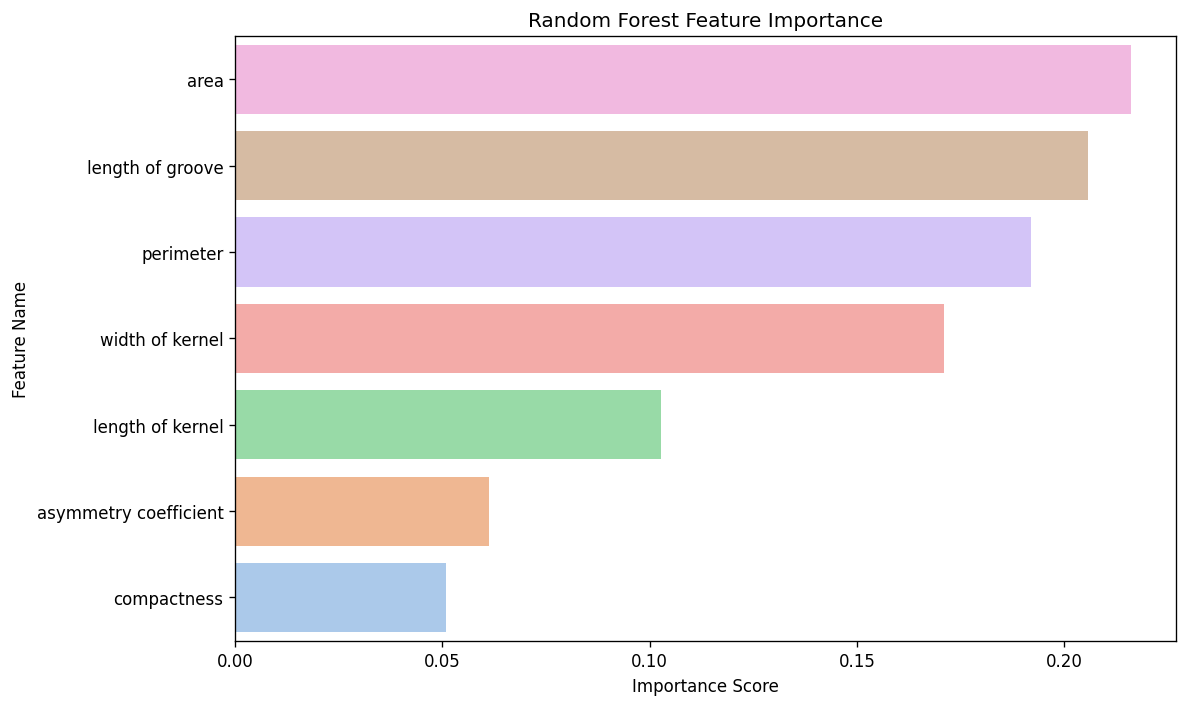

In [20]:
plot_feature_importances(rf_custom, X.columns.tolist())